# Exploratory Data Analysis - Used Car Pricing

This notebook performs comprehensive exploratory data analysis on the used car dataset to understand:
- Distribution of key variables
- Relationships between features and price
- Data quality and outliers
- Feature correlations
- Market insights

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

In [5]:
df = pd.read_csv('data/cleaned_cardekho_used_cars.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset shape: (451, 12)

Columns: ['brand', 'name', 'price', 'registration_yr', 'insurance', 'fuel_type', 'seats', 'km_driven', 'ownership', 'engine_displacement', 'transmission', 'manufacture_yr']


,brand,name,price,registration_yr,insurance,fuel_type,seats,km_driven,ownership,engine_displacement,transmission,manufacture_yr
0,Tata,Tata Nexon Creative Plus S,997000.0,2024,Own Damage,Petrol,5,10000,First Owner,1199.0,Manual,2024
1,Kia,Kia Sonet HTX Plus Turbo iMT DT,850000.0,2022,Comprehensive,Petrol,5,28000,First Owner,998.0,Manual,2022
2,Tata,Tata Hexa XTA,725000.0,2018,Comprehensive,Diesel,7,82000,First Owner,2179.0,Automatic,2018
3,Kia,Kia Seltos HTX IVT G,950000.0,2020,Zero Dep,Petrol,5,90000,First Owner,1497.0,Automatic,2020
4,Hyundai,Hyundai Creta 1.4 E Plus,735000.0,2019,Own Damage,Diesel,5,70000,First Owner,1396.0,Manual,2019


In [6]:
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451 entries, 0 to 450
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                451 non-null    object 
 1   name                 451 non-null    object 
 2   price                451 non-null    float64
 3   registration_yr      451 non-null    int64  
 4   insurance            451 non-null    object 
 5   fuel_type            451 non-null    object 
 6   seats                451 non-null    int64  
 7   km_driven            451 non-null    int64  
 8   ownership            448 non-null    object 
 9   engine_displacement  448 non-null    float64
 10  transmission         451 non-null    object 
 11  manufacture_yr       451 non-null    int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 42.4+ KB
None


Basic Statistics:


,price,registration_yr,seats,km_driven,engine_displacement,manufacture_yr
count,4.510000e+02,451.000000,451.000000,451.000000,448.000000,451.000000
mean,1.105785e+06,2020.634146,5.332594,46400.099778,1525.808036,2020.534368
std,4.873670e+05,2.991333,0.794580,30426.237112,373.282535,2.975536
min,1.350000e+05,2011.000000,4.000000,100.000000,814.000000,2011.000000
25%,7.055000e+05,2019.000000,5.000000,25071.500000,1248.000000,2019.000000
50%,1.050000e+06,2021.000000,5.000000,42000.000000,1493.000000,2021.000000
75%,1.525000e+06,2023.000000,5.000000,65000.000000,1591.000000,2023.000000
max,2.000000e+06,2025.000000,8.000000,280000.000000,3198.000000,2025.000000


In [7]:
print("Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing, 'Percentage': missing_pct})
missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

Missing Values:


,Missing_Count,Percentage
ownership,3,0.665188
engine_displacement,3,0.665188


## 1. Price Distribution Analysis

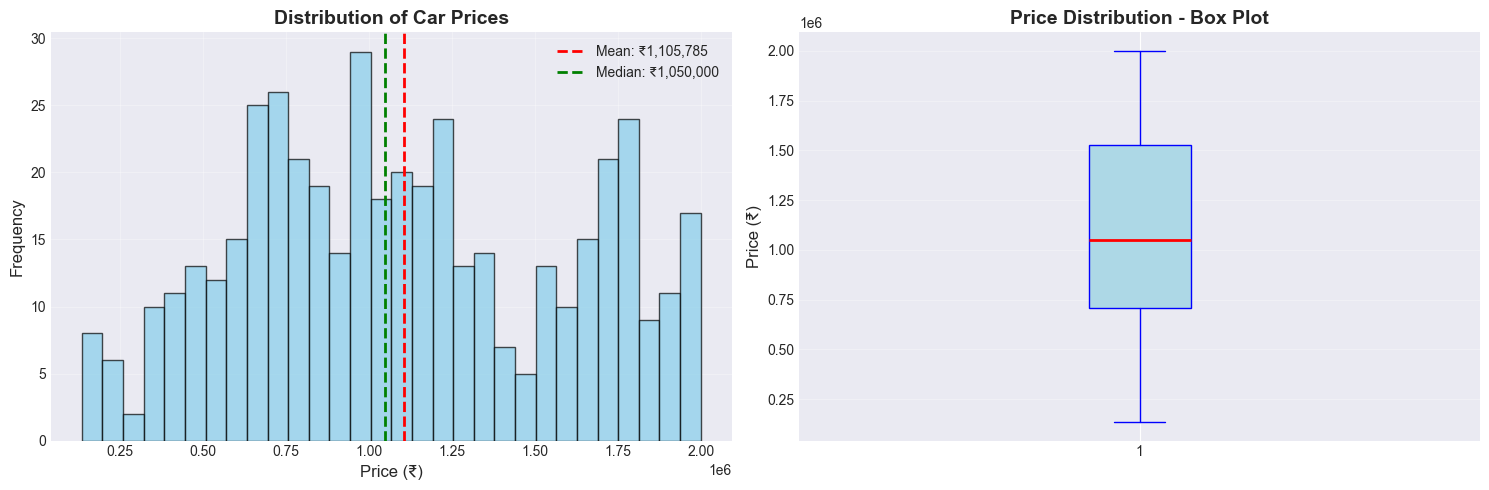

Price Statistics:
Mean: ₹1,105,785
Median: ₹1,050,000
Std Dev: ₹487,367
Min: ₹135,000
Max: ₹2,000,000


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df['price'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Price (₹)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Car Prices', fontsize=14, fontweight='bold')
axes[0].axvline(df['price'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ₹{df["price"].mean():,.0f}')
axes[0].axvline(df['price'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: ₹{df["price"].median():,.0f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(df['price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='blue'),
                whiskerprops=dict(color='blue'),
                capprops=dict(color='blue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Price (₹)', fontsize=12)
axes[1].set_title('Price Distribution - Box Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Price Statistics:")
print(f"Mean: ₹{df['price'].mean():,.0f}")
print(f"Median: ₹{df['price'].median():,.0f}")
print(f"Std Dev: ₹{df['price'].std():,.0f}")
print(f"Min: ₹{df['price'].min():,.0f}")
print(f"Max: ₹{df['price'].max():,.0f}")

## 2. Brand Analysis

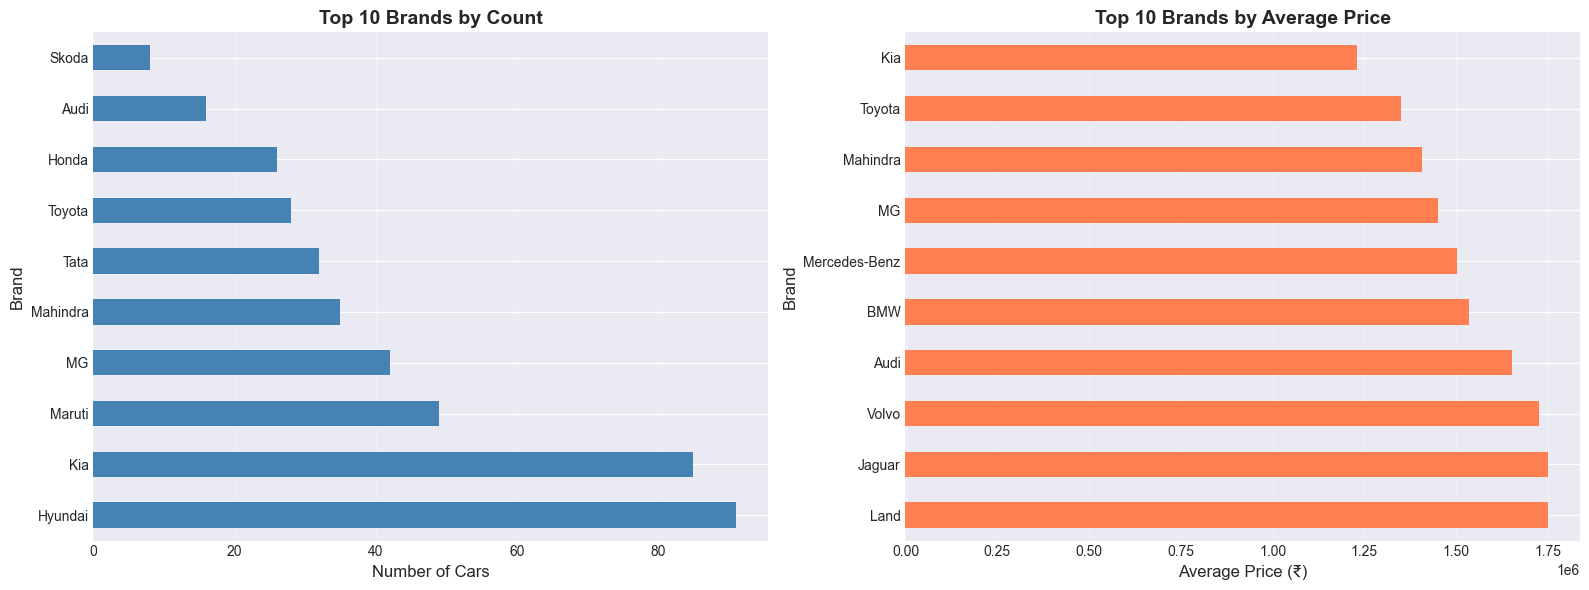

In [9]:
brand_counts = df['brand'].value_counts().head(10)
brand_avg_price = df.groupby('brand')['price'].mean().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

brand_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Number of Cars', fontsize=12)
axes[0].set_ylabel('Brand', fontsize=12)
axes[0].set_title('Top 10 Brands by Count', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

brand_avg_price.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_xlabel('Average Price (₹)', fontsize=12)
axes[1].set_ylabel('Brand', fontsize=12)
axes[1].set_title('Top 10 Brands by Average Price', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_5648\956536394.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_brands, x='brand', y='price', palette='Set2')


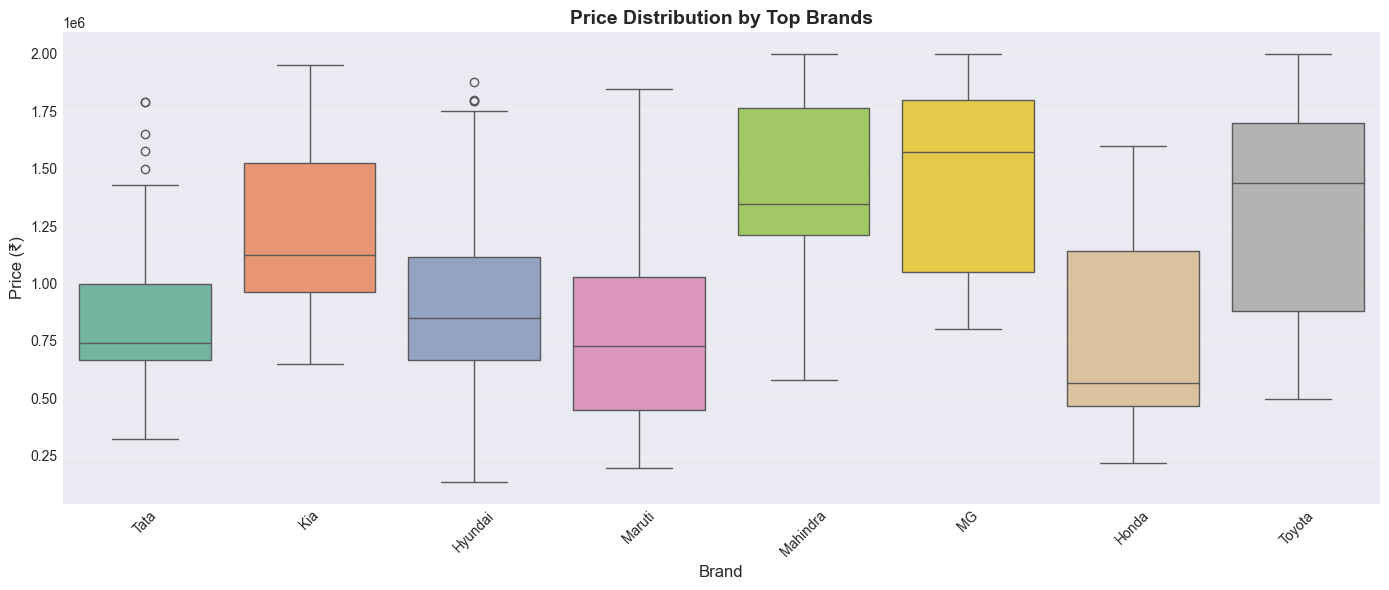

In [10]:
top_brands = df['brand'].value_counts().head(8).index
df_top_brands = df[df['brand'].isin(top_brands)]

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_top_brands, x='brand', y='price', palette='Set2')
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Price (₹)', fontsize=12)
plt.title('Price Distribution by Top Brands', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 3. Manufacture Year vs Price

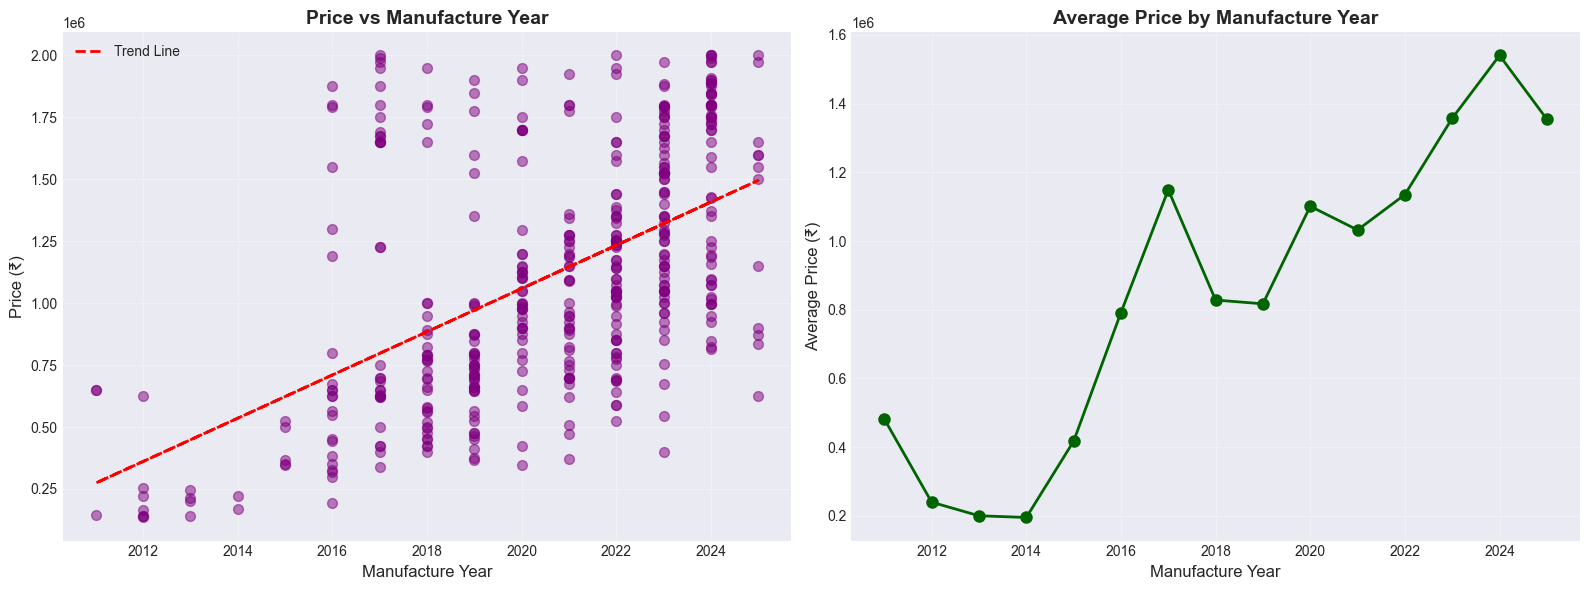

Correlation between Manufacture Year and Price: 0.533


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df['manufacture_yr'], df['price'], alpha=0.5, color='purple', s=50)
axes[0].set_xlabel('Manufacture Year', fontsize=12)
axes[0].set_ylabel('Price (₹)', fontsize=12)
axes[0].set_title('Price vs Manufacture Year', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

z = np.polyfit(df['manufacture_yr'], df['price'], 1)
p = np.poly1d(z)
axes[0].plot(df['manufacture_yr'], p(df['manufacture_yr']), "r--", linewidth=2, label='Trend Line')
axes[0].legend()

year_avg = df.groupby('manufacture_yr')['price'].mean().sort_index()
axes[1].plot(year_avg.index, year_avg.values, marker='o', linewidth=2, markersize=8, color='darkgreen')
axes[1].set_xlabel('Manufacture Year', fontsize=12)
axes[1].set_ylabel('Average Price (₹)', fontsize=12)
axes[1].set_title('Average Price by Manufacture Year', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

correlation = df['manufacture_yr'].corr(df['price'])
print(f"Correlation between Manufacture Year and Price: {correlation:.3f}")

## 4. Kilometers Driven Analysis

C:\Users\Admin\AppData\Local\Temp\ipykernel_5648\783438608.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  km_price = df.groupby(km_bins)['price'].mean()


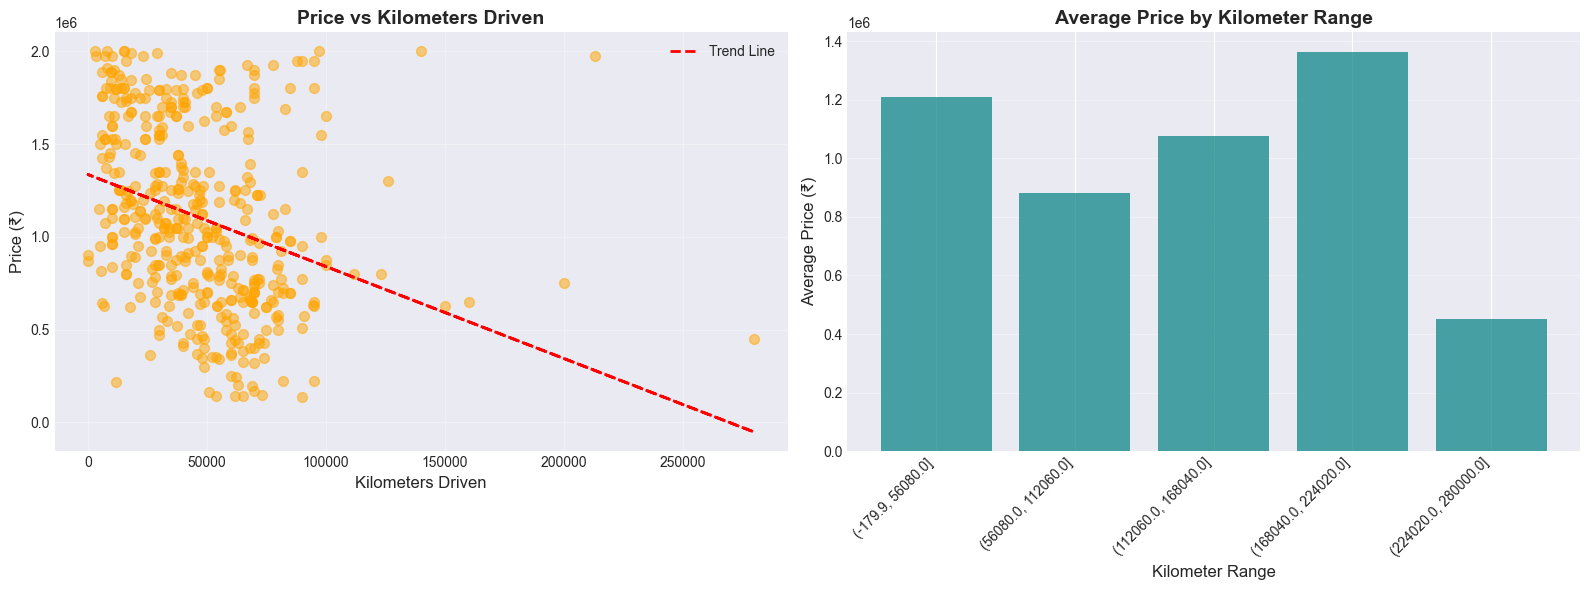

Correlation between KM Driven and Price: -0.310


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df['km_driven'], df['price'], alpha=0.5, color='orange', s=50)
axes[0].set_xlabel('Kilometers Driven', fontsize=12)
axes[0].set_ylabel('Price (₹)', fontsize=12)
axes[0].set_title('Price vs Kilometers Driven', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

z = np.polyfit(df['km_driven'], df['price'], 1)
p = np.poly1d(z)
axes[0].plot(df['km_driven'], p(df['km_driven']), "r--", linewidth=2, label='Trend Line')
axes[0].legend()

km_bins = pd.cut(df['km_driven'], bins=5)
km_price = df.groupby(km_bins)['price'].mean()
axes[1].bar(range(len(km_price)), km_price.values, color='teal', alpha=0.7)
axes[1].set_xlabel('Kilometer Range', fontsize=12)
axes[1].set_ylabel('Average Price (₹)', fontsize=12)
axes[1].set_title('Average Price by Kilometer Range', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(len(km_price)))
axes[1].set_xticklabels([str(x) for x in km_price.index], rotation=45, ha='right')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

correlation = df['km_driven'].corr(df['price'])
print(f"Correlation between KM Driven and Price: {correlation:.3f}")

## 5. Categorical Features Analysis

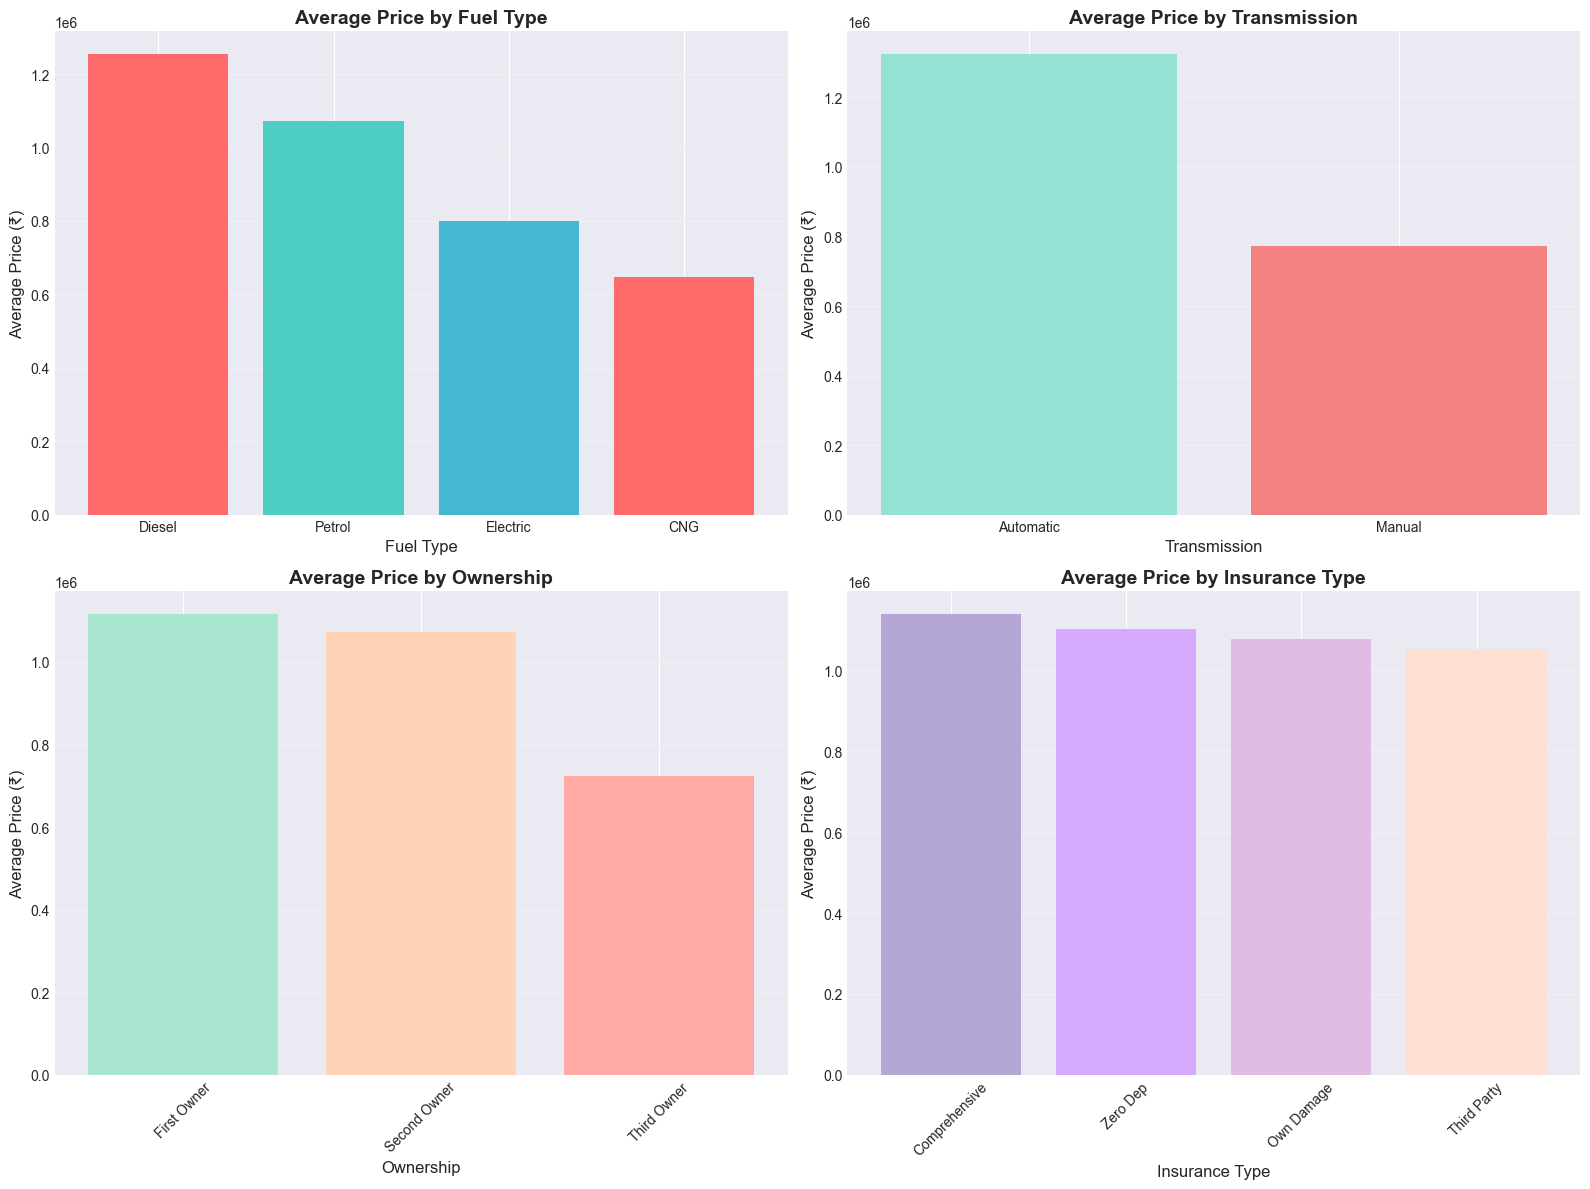

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

fuel_avg = df.groupby('fuel_type')['price'].mean().sort_values(ascending=False)
axes[0, 0].bar(fuel_avg.index, fuel_avg.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0, 0].set_xlabel('Fuel Type', fontsize=12)
axes[0, 0].set_ylabel('Average Price (₹)', fontsize=12)
axes[0, 0].set_title('Average Price by Fuel Type', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')

trans_avg = df.groupby('transmission')['price'].mean().sort_values(ascending=False)
axes[0, 1].bar(trans_avg.index, trans_avg.values, color=['#95E1D3', '#F38181'])
axes[0, 1].set_xlabel('Transmission', fontsize=12)
axes[0, 1].set_ylabel('Average Price (₹)', fontsize=12)
axes[0, 1].set_title('Average Price by Transmission', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

owner_avg = df.groupby('ownership')['price'].mean().sort_values(ascending=False)
axes[1, 0].bar(owner_avg.index, owner_avg.values, color=['#A8E6CF', '#FFD3B6', '#FFAAA5'])
axes[1, 0].set_xlabel('Ownership', fontsize=12)
axes[1, 0].set_ylabel('Average Price (₹)', fontsize=12)
axes[1, 0].set_title('Average Price by Ownership', fontsize=14, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

ins_avg = df.groupby('insurance')['price'].mean().sort_values(ascending=False)
axes[1, 1].bar(ins_avg.index, ins_avg.values, color=['#B4A7D6', '#D5AAFF', '#E0BBE4', '#FFDFD3'])
axes[1, 1].set_xlabel('Insurance Type', fontsize=12)
axes[1, 1].set_ylabel('Average Price (₹)', fontsize=12)
axes[1, 1].set_title('Average Price by Insurance Type', fontsize=14, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. Engine Displacement vs Price

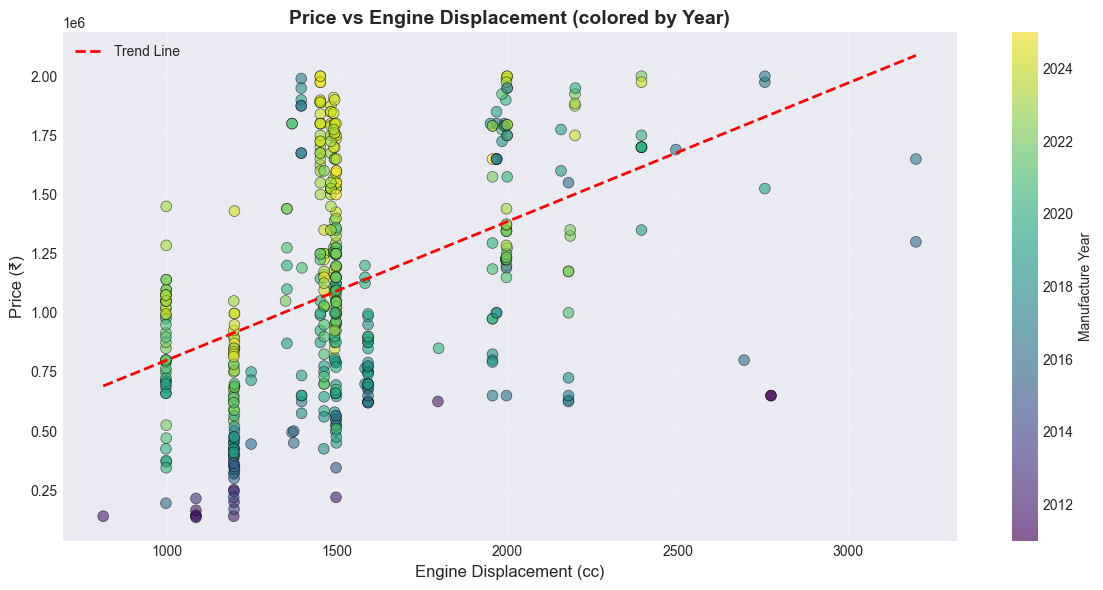

Correlation between Engine Displacement and Price: 0.448


In [14]:
plt.figure(figsize=(12, 6))
plt.scatter(df['engine_displacement'], df['price'], alpha=0.6, c=df['manufacture_yr'], 
            cmap='viridis', s=60, edgecolors='black', linewidth=0.5)
plt.colorbar(label='Manufacture Year')
plt.xlabel('Engine Displacement (cc)', fontsize=12)
plt.ylabel('Price (₹)', fontsize=12)
plt.title('Price vs Engine Displacement (colored by Year)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

z = np.polyfit(df['engine_displacement'].dropna(), df[df['engine_displacement'].notna()]['price'], 1)
p = np.poly1d(z)
plt.plot(sorted(df['engine_displacement'].dropna()), p(sorted(df['engine_displacement'].dropna())), 
         "r--", linewidth=2, label='Trend Line')
plt.legend()
plt.tight_layout()
plt.show()

correlation = df['engine_displacement'].corr(df['price'])
print(f"Correlation between Engine Displacement and Price: {correlation:.3f}")

## 7. Correlation Heatmap

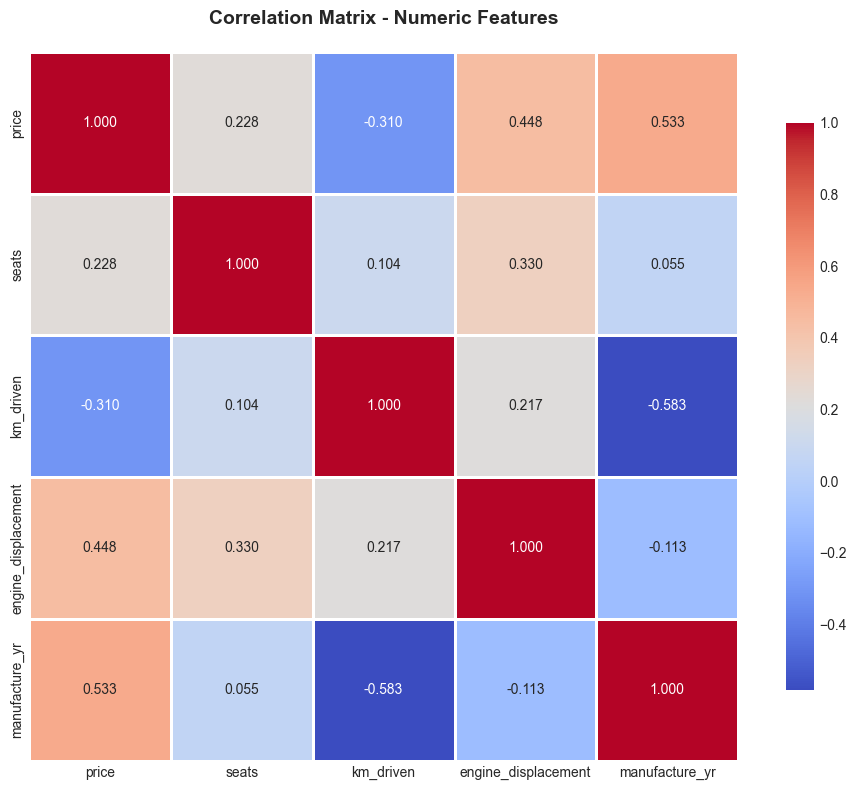


Correlations with Price:
price                  1.000000
manufacture_yr         0.532783
engine_displacement    0.448208
seats                  0.228374
km_driven             -0.309618
Name: price, dtype: float64


In [15]:
numeric_cols = ['price', 'seats', 'km_driven', 'engine_displacement', 'manufacture_yr']
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Numeric Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nCorrelations with Price:")
print(correlation_matrix['price'].sort_values(ascending=False))

## 8. Seats Distribution

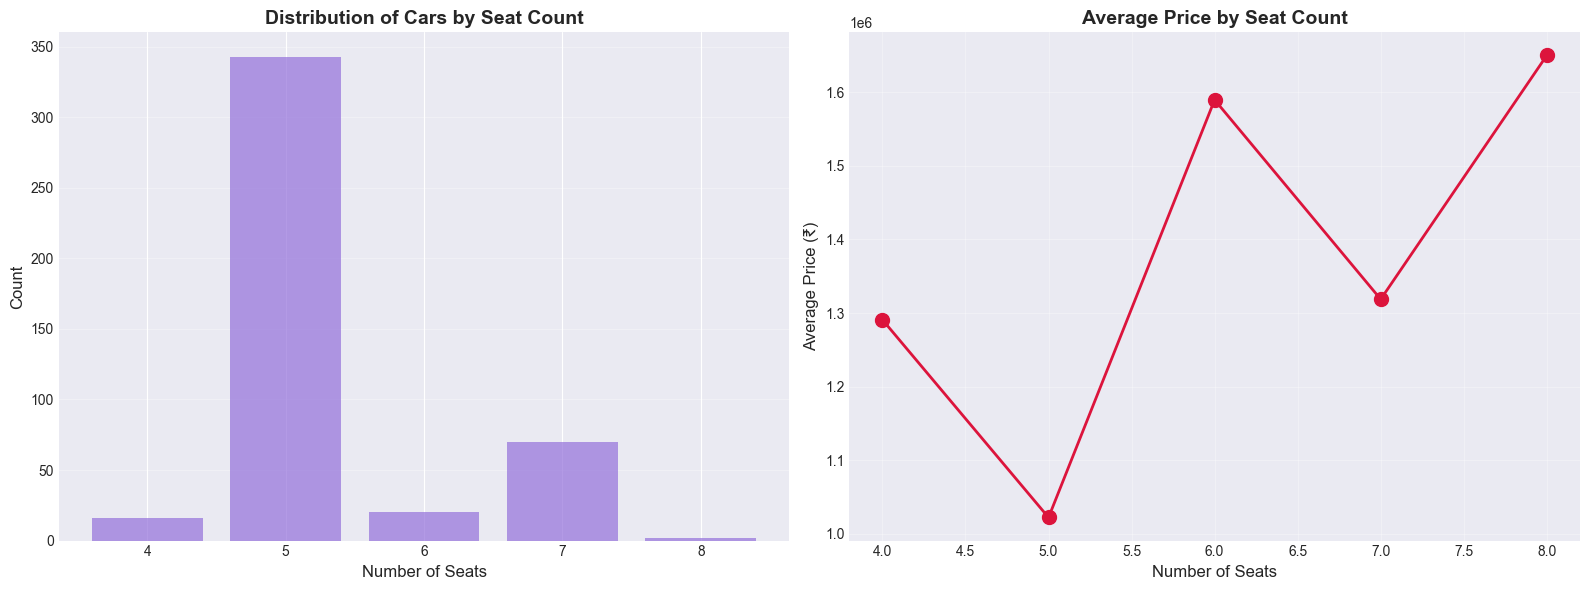

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

seat_counts = df['seats'].value_counts().sort_index()
axes[0].bar(seat_counts.index, seat_counts.values, color='mediumpurple', alpha=0.7)
axes[0].set_xlabel('Number of Seats', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Distribution of Cars by Seat Count', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

seat_avg = df.groupby('seats')['price'].mean().sort_index()
axes[1].plot(seat_avg.index, seat_avg.values, marker='o', linewidth=2, markersize=10, color='crimson')
axes[1].set_xlabel('Number of Seats', fontsize=12)
axes[1].set_ylabel('Average Price (₹)', fontsize=12)
axes[1].set_title('Average Price by Seat Count', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Price Distribution by Transmission and Fuel Type

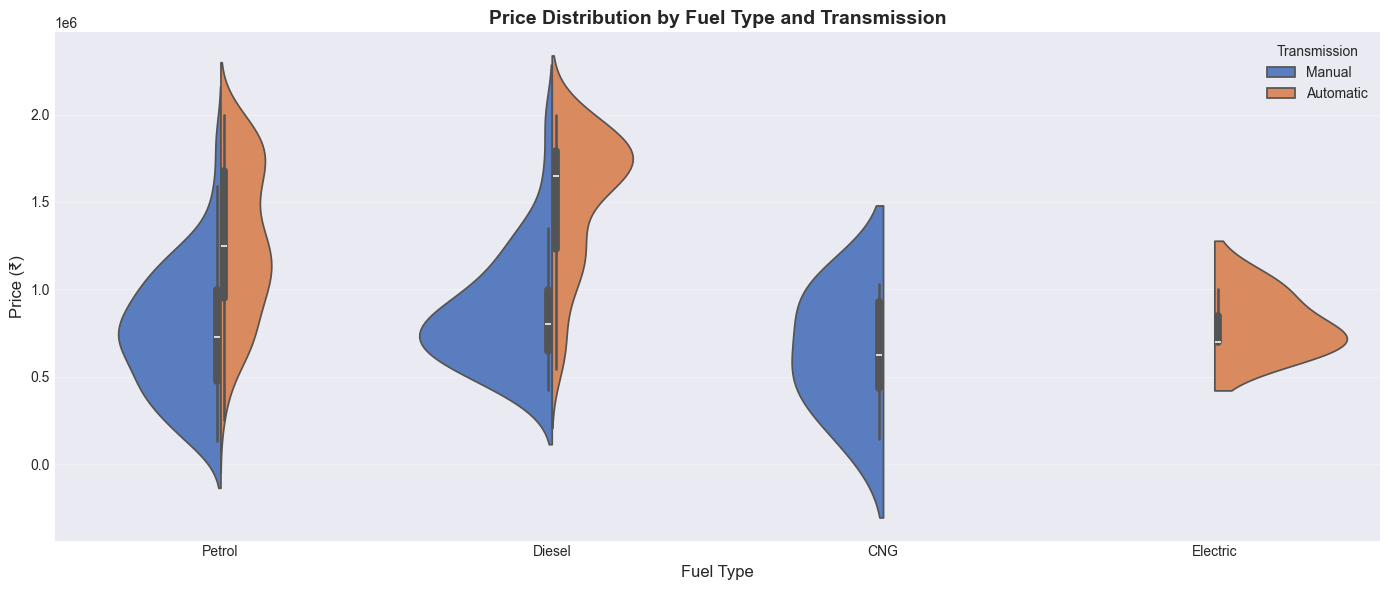

In [17]:
plt.figure(figsize=(14, 6))
sns.violinplot(data=df, x='fuel_type', y='price', hue='transmission', split=True, palette='muted')
plt.xlabel('Fuel Type', fontsize=12)
plt.ylabel('Price (₹)', fontsize=12)
plt.title('Price Distribution by Fuel Type and Transmission', fontsize=14, fontweight='bold')
plt.legend(title='Transmission', loc='upper right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 10. Key Insights Summary

In [18]:
print("="*70)
print("KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS")
print("="*70)

print("\n1. PRICE DISTRIBUTION:")
print(f"   - Average price: ₹{df['price'].mean():,.0f}")
print(f"   - Median price: ₹{df['price'].median():,.0f}")
print(f"   - Price range: ₹{df['price'].min():,.0f} - ₹{df['price'].max():,.0f}")

print("\n2. BRAND INSIGHTS:")
top_3_brands = df['brand'].value_counts().head(3)
print(f"   - Most common brands: {', '.join(top_3_brands.index.tolist())}")
expensive_brand = df.groupby('brand')['price'].mean().idxmax()
print(f"   - Highest average price: {expensive_brand}")

print("\n3. DEPRECIATION PATTERN:")
year_corr = df['manufacture_yr'].corr(df['price'])
print(f"   - Year-Price correlation: {year_corr:.3f} (Strong positive)")
print(f"   - Newer cars command significantly higher prices")

print("\n4. MILEAGE IMPACT:")
km_corr = df['km_driven'].corr(df['price'])
print(f"   - KM-Price correlation: {km_corr:.3f}")
print(f"   - Higher mileage reduces car value")

print("\n5. TRANSMISSION PREMIUM:")
trans_diff = df.groupby('transmission')['price'].mean()
if 'Automatic' in trans_diff.index and 'Manual' in trans_diff.index:
    premium = trans_diff['Automatic'] - trans_diff['Manual']
    print(f"   - Automatic transmission premium: ₹{premium:,.0f}")

print("\n6. FUEL TYPE:")
fuel_avg = df.groupby('fuel_type')['price'].mean().sort_values(ascending=False)
print(f"   - Highest avg price fuel: {fuel_avg.index[0]} (₹{fuel_avg.values[0]:,.0f})")

print("\n7. OWNERSHIP EFFECT:")
owner_avg = df.groupby('ownership')['price'].mean().sort_values(ascending=False)
print(f"   - First owner premium confirmed")
if len(owner_avg) >= 2:
    discount = ((owner_avg.iloc[0] - owner_avg.iloc[1]) / owner_avg.iloc[0]) * 100
    print(f"   - Second owner discount: ~{discount:.1f}%")

print("\n8. ENGINE SIZE:")
engine_corr = df['engine_displacement'].corr(df['price'])
print(f"   - Engine-Price correlation: {engine_corr:.3f}")
print(f"   - Larger engines associated with higher prices")

print("\n9. DATA QUALITY:")
print(f"   - Total records: {len(df)}")
print(f"   - Missing values: {df.isnull().sum().sum()}")
print(f"   - Data completeness: {((1 - df.isnull().sum().sum() / (len(df) * len(df.columns))) * 100):.1f}%")

print("\n" + "="*70)

KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS

1. PRICE DISTRIBUTION:
   - Average price: ₹1,105,785
   - Median price: ₹1,050,000
   - Price range: ₹135,000 - ₹2,000,000

2. BRAND INSIGHTS:
   - Most common brands: Hyundai, Kia, Maruti
   - Highest average price: Jaguar

3. DEPRECIATION PATTERN:
   - Year-Price correlation: 0.533 (Strong positive)
   - Newer cars command significantly higher prices

4. MILEAGE IMPACT:
   - KM-Price correlation: -0.310
   - Higher mileage reduces car value

5. TRANSMISSION PREMIUM:
   - Automatic transmission premium: ₹551,835

6. FUEL TYPE:
   - Highest avg price fuel: Diesel (₹1,253,837)

7. OWNERSHIP EFFECT:
   - First owner premium confirmed
   - Second owner discount: ~3.9%

8. ENGINE SIZE:
   - Engine-Price correlation: 0.448
   - Larger engines associated with higher prices

9. DATA QUALITY:
   - Total records: 451
   - Missing values: 6
   - Data completeness: 99.9%

